<a href="https://colab.research.google.com/github/Luccadr/projects/blob/main/Cancer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cancer Data Analysis and Modeling Project**

---

This project aims to explore and apply advanced statistical and machine learning techniques to understand and predict various aspects of cancer on a global scale. From feature selection to predictive modeling, we generate valuable insights for healthcare professionals, researchers, and analytics developers.

### Key Tasks
- **Multiple Linear Regression & Advanced Modeling**  
  Implementation of various algorithms (multiple regression, decision trees, ensemble methods, etc.) to predict key outcomes.  
- **Feature Selection & Correlation Analysis**  
  Identification of the most relevant features and assessment of statistical relationships between clinical factors and outcomes.  
- **Predictive Modeling**  
  - *Disease Severity*  
  - *Treatment Cost Estimation*  
  - *Survival Projection*  
- **Data Visualization**  
  Creation of interactive charts and dashboards to facilitate result interpretation and communication with non-technical audiences.

### Dataset Description

| Variable                | Description                                                            |
|-------------------------|------------------------------------------------------------------------|
| **Age**                 | Patient age (20–90 years)                                              |
| **Gender**              | Male, Female, or Other                                                 |
| **Country/Region**      | Geographical location of the patient                                   |
| **Cancer Type**         | Examples: Breast, Lung, Colon                                          |
| **Cancer Stage**        | Stage 0 through Stage IV                                               |
| **Risk Factors**        | Genetic predisposition, air pollution exposure, alcohol use, smoking, obesity, etc. |
| **Treatment Cost**      | Estimated cost of cancer treatment (in USD)                            |
| **Survival Years**      | Years survived since diagnosis                                         |
| **Severity Score**      | Composite score representing overall cancer severity                   |

> This dataset provides a comprehensive view of global cancer trends, making it an ideal resource for learning and applying data science, machine learning, and statistical analysis techniques in healthcare.

# Import Libraries & Load Dataset

In [ ]:
import kagglehub

#-----------------------------------------

import pandas as pd
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
import zipfile
import glob
import pandas as pd
from pathlib import Path
import kagglehub

# 1. Baixa o dataset (retorna string com caminho para .zip ou diretório já extraído)
path = kagglehub.dataset_download("zahidmughal2343/global-cancer-patients-2015-2024")

# 2. Cria um objeto Path para facilitar a lógica
p = Path(path)

# 3. Se for um arquivo compactado, extrai para uma pasta “data/global_cancer”
if p.is_file() and p.suffix in {'.zip', '.gz', '.tgz', '.tar'}:
    extract_dir = Path("data/global_cancer")
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(p, 'r') as z:
        z.extractall(extract_dir)
# 4. Se já for diretório, usamos ele diretamente
elif p.is_dir():
    extract_dir = p
else:
    raise RuntimeError(f"Formato inesperado: {p}")

# 5. Agora liste recursivamente tudo que foi extraído
print("Arquivos extraídos:")
for file in extract_dir.rglob('*'):
    print(" -", file.relative_to(extract_dir))

# 6. Filtre só CSVs e carregue num pandas DataFrame
csv_paths = list(extract_dir.rglob("*.csv"))
dfs = {}
for csv in csv_paths:
    name = csv.stem
    dfs[name] = pd.read_csv(csv)
    print(f"'{name}': {dfs[name].shape} linhas×colunas")



Arquivos extraídos:
 - global_cancer_patients_2015_2024.csv
'global_cancer_patients_2015_2024': (50000, 15) linhas×colunas


In [ ]:
import pandas as pd
from pathlib import Path

# Supondo que você ainda tenha essa variável:
# path = kagglehub.dataset_download("zahidmughal2343/global-cancer-patients-2015-2024")

# 1. Veja onde exatamente está:
print("Dataset em:", path)

# 2. Aponte para o arquivo CSV dentro desse diretório:
csv_file = Path(path) / "global_cancer_patients_2015_2024.csv"

# 3. Carregue no pandas:
df = pd.read_csv(csv_file)



Dataset em: /kaggle/input/global-cancer-patients-2015-2024


# Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [ ]:
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


## Null Values

In [ ]:
# Quantos valores nulos por coluna
print(df.isna().sum())



Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64


## Distribuições univariadas



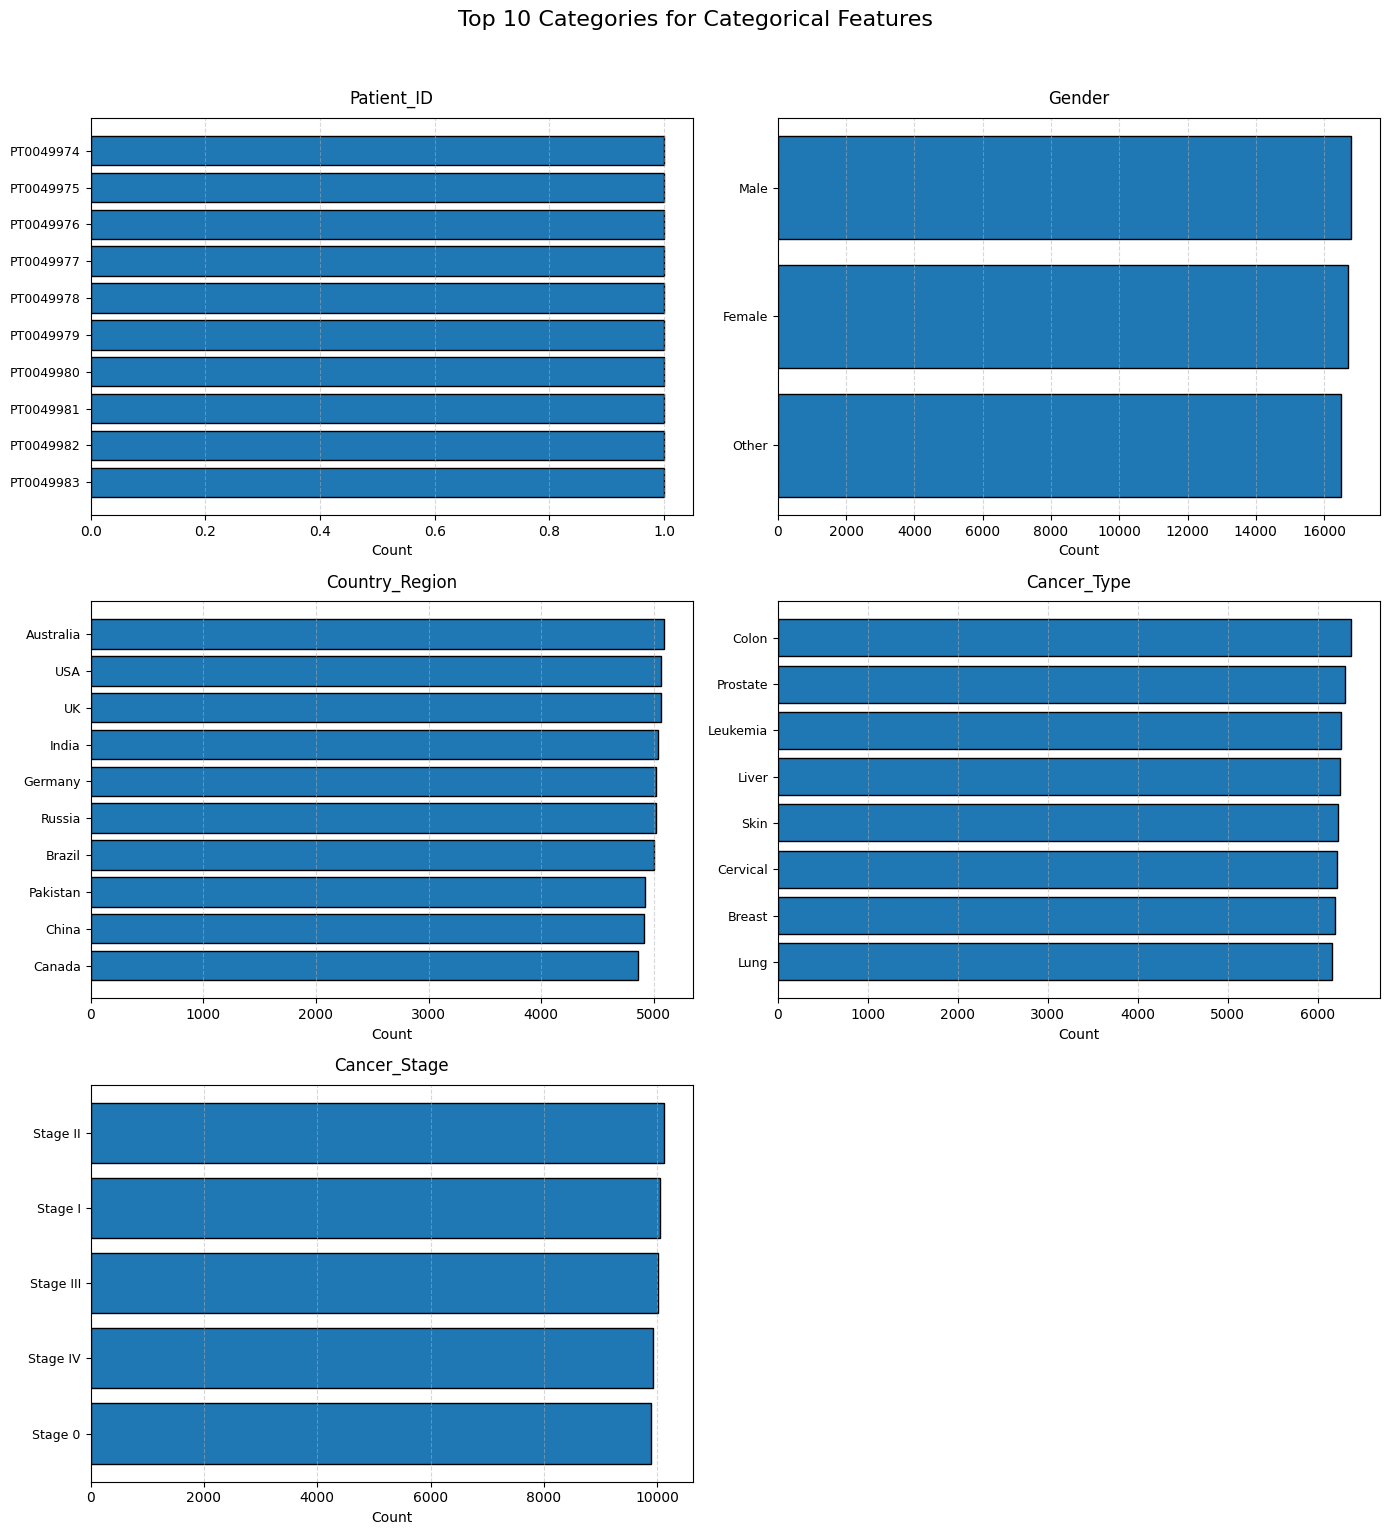

In [ ]:
import matplotlib.pyplot as plt



categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# colunas por linha
n = len(categorical_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5*nrows))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts().nlargest(10).sort_values()
    ax.barh(counts.index, counts.values, edgecolor='black')
    ax.set_title(col, fontsize=12, pad=10)
    ax.set_xlabel('Count', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# Remove subplots extras
for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Top 10 Categories for Categorical Features', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


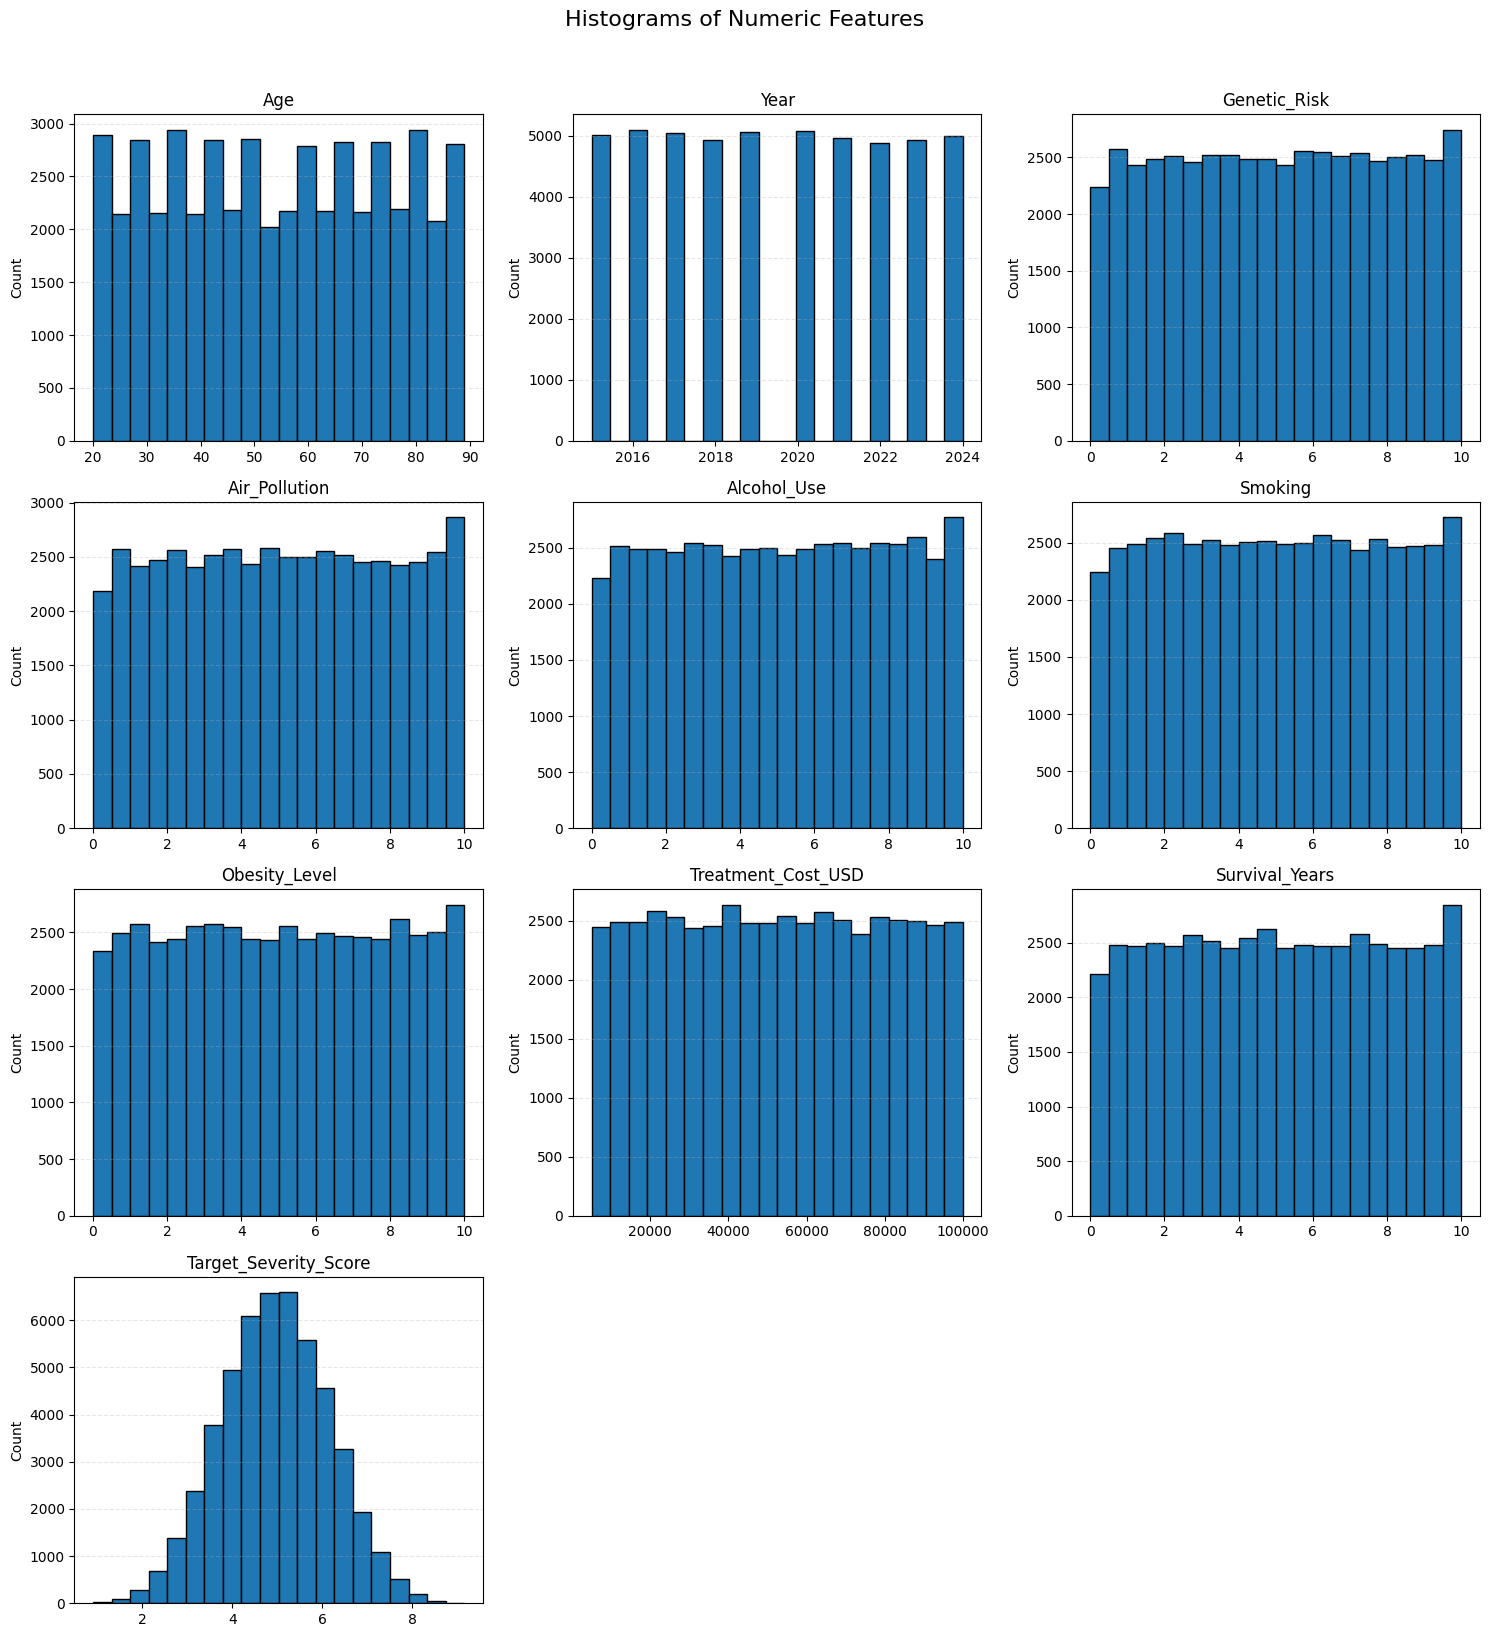

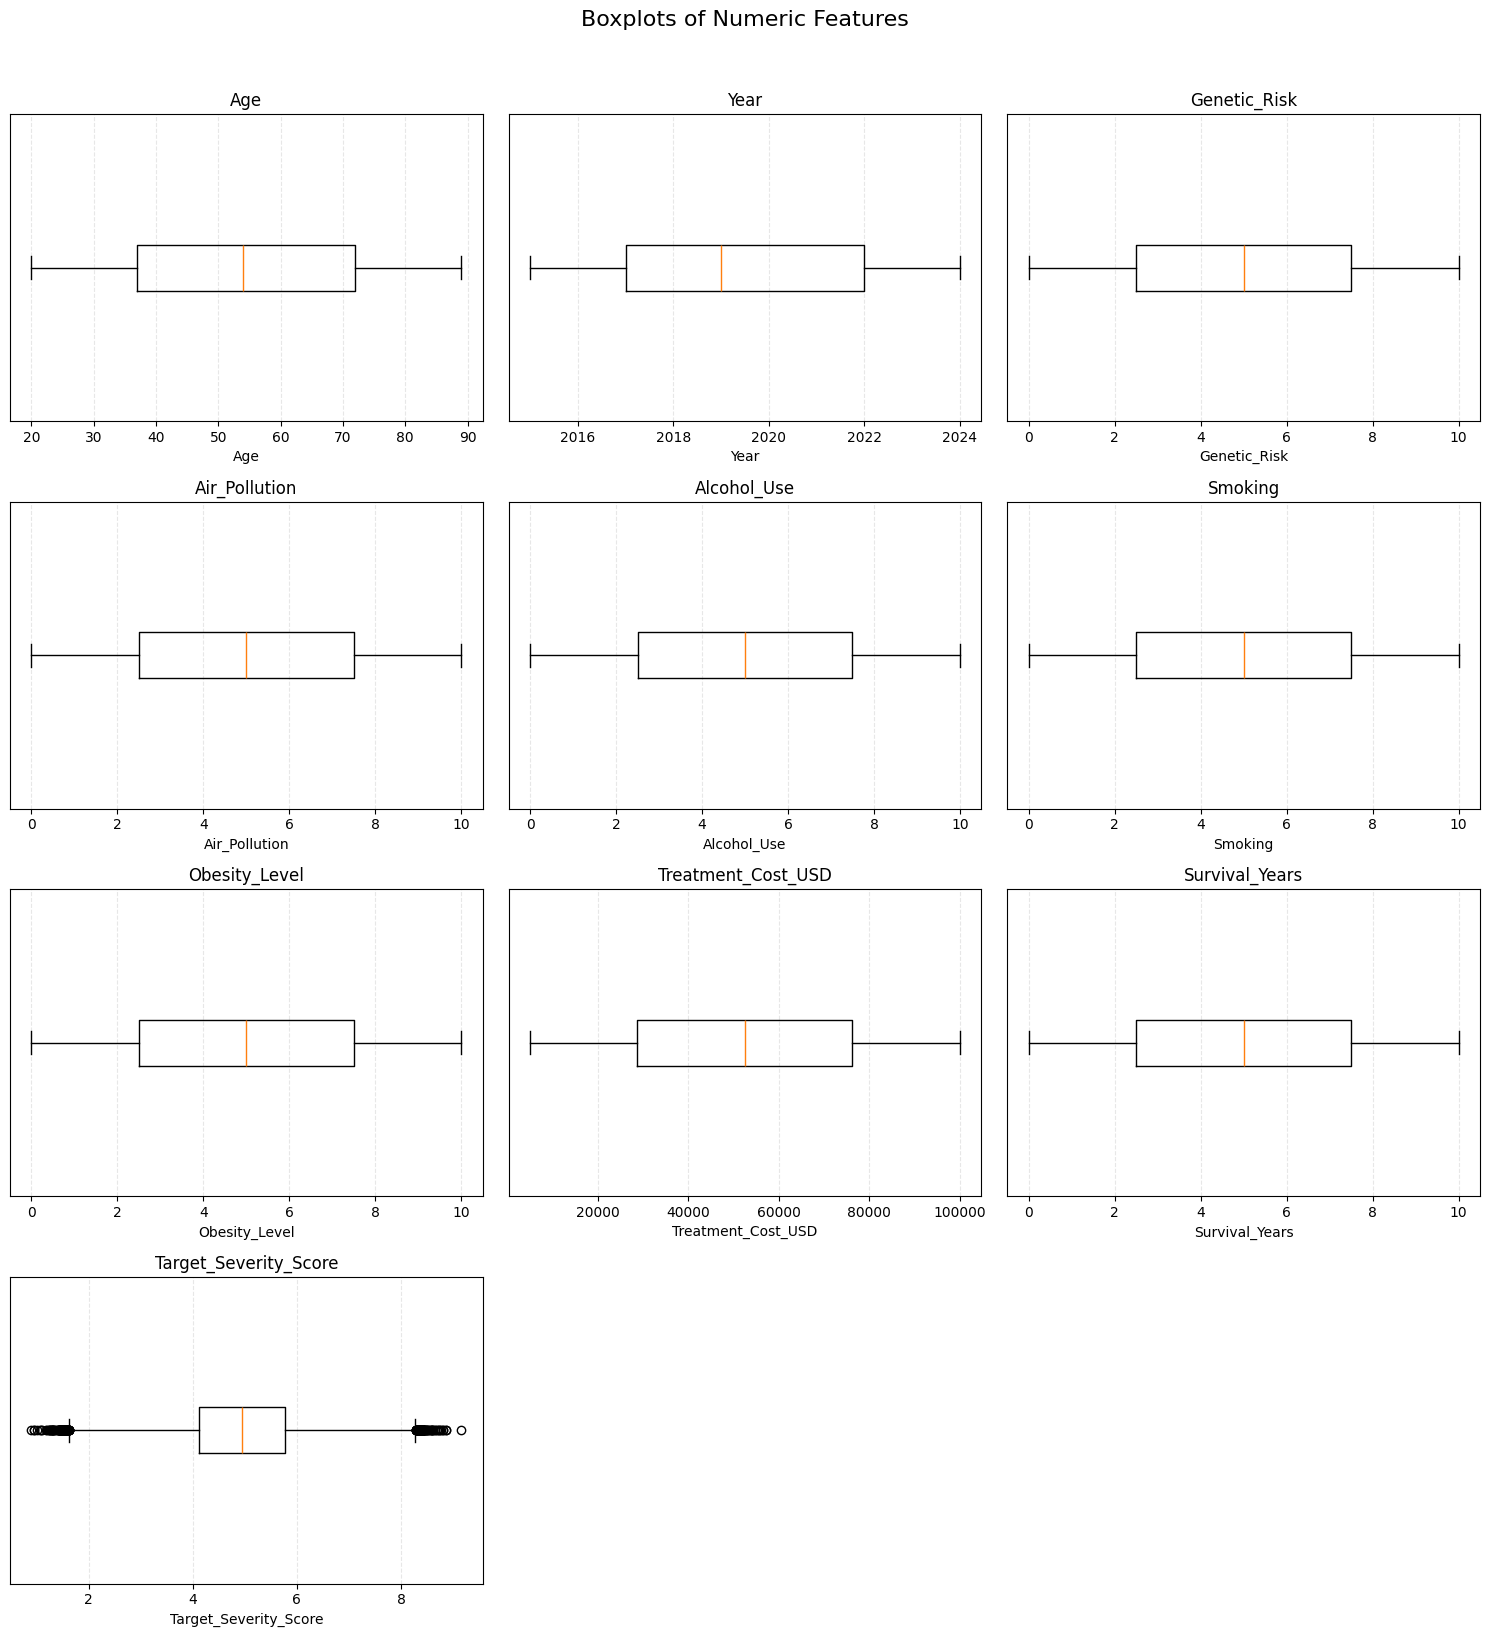

In [ ]:
import matplotlib.pyplot as plt

# ————— Ajuste aqui se necessário —————
# df = pd.read_csv("seu_caminho.csv")

# Seleciona só colunas numéricas
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Define layout: 3 colunas por linha (ajuste se quiser)
ncols = 3
n = len(numeric_cols)
nrows = (n + ncols - 1) // ncols

# ————— 1) Grid de Histogramas —————
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=20, edgecolor='black')
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Remove subplots extras
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Histograms of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# ————— 2) Grid de Boxplots —————
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col)
    ax.set_yticks([])  # esconde eixo y, pois a variável já está no título
    ax.grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Boxplots of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
